<a href="https://colab.research.google.com/github/visheshgupta19/IDS_705_Final_Project/blob/main/LSTM_ClosePrice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd

ticker = "GLD"
gold_data = yf.download(
    ticker,
    start="2000-01-01",
    end=None,
    progress=False,
    auto_adjust=False,
    actions=True,
)
gold_data

Price,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD
Date,,,,,,,,,
2004-11-18,44.380001,0.0,44.380001,0.0,44.490002,44.070000,44.430000,0.0,5992000
2004-11-19,44.779999,0.0,44.779999,0.0,44.919998,44.470001,44.490002,0.0,11655300
2004-11-22,44.950001,0.0,44.950001,0.0,44.970001,44.740002,44.750000,0.0,11996000
2004-11-23,44.750000,0.0,44.750000,0.0,44.919998,44.720001,44.880001,0.0,3169200
2004-11-24,45.049999,0.0,45.049999,0.0,45.049999,44.790001,44.930000,0.0,6105100
...,...,...,...,...,...,...,...,...,...
2025-04-21,315.589996,0.0,315.589996,0.0,316.410004,313.950012,315.019989,0.0,20372300
2025-04-22,311.109985,0.0,311.109985,0.0,317.630005,310.359985,317.489990,0.0,35242300


In [2]:
gold_data.reset_index(inplace=True)
gold_data.columns = [col[0] for col in gold_data.columns]

gold_data["Date"] = pd.to_datetime(gold_data["Date"])

In [3]:
df = gold_data[["Date", "Close"]]

df

,Date,Close
0,2004-11-18,44.380001
1,2004-11-19,44.779999
2,2004-11-22,44.950001
3,2004-11-23,44.750000
4,2004-11-24,45.049999
...,...,...
5136,2025-04-21,315.589996
5137,2025-04-22,311.109985
5138,2025-04-23,303.649994
5139,2025-04-24,308.070007


In [4]:
# make date the index
df.index = df.pop("Date")
df

,Close
Date,
2004-11-18,44.380001
2004-11-19,44.779999
2004-11-22,44.950001
2004-11-23,44.750000
2004-11-24,45.049999
...,...
2025-04-21,315.589996
2025-04-22,311.109985
2025-04-23,303.649994


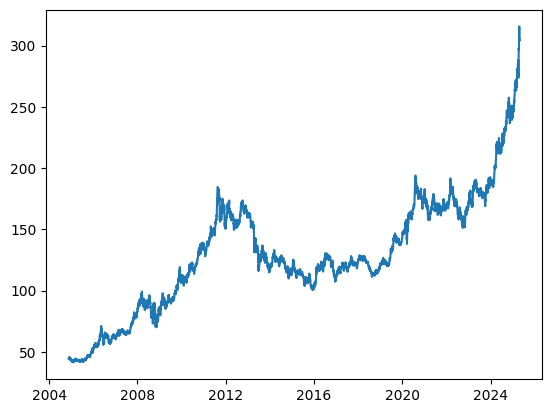

In [5]:
import matplotlib.pyplot as plt

plt.plot(df.index, df["Close"])

In [6]:
import numpy as np

close_prices = df['Close'].values


<ipython-input-14-fa16bb871410>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Return'] = df['Close'].pct_change().shift(-1)  # percentage return for next day
<ipython-input-14-fa16bb871410>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)  # remove NaNs caused by shifting


Epoch 1/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4830 - val_loss: 0.0242
Epoch 2/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012 - val_loss: 0.0130
Epoch 3/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.5103e-04 - val_loss: 0.0054
Epoch 4/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.0130e-04 - val_loss: 0.0053
Epoch 5/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.1639e-04 - val_loss: 0.0037
Epoch 6/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.4986e-04 - val_loss: 0.0025
Epoch 7/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.1505e-04 - val_loss: 0.0031
Epoch 8/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9346e-04 - val_loss: 0.0022
Epoch 9/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7841e-04 - val_loss: 0.0023
Epoch 10/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5848e-04 - val_loss: 0.0026
Epoch 11/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2347e-04 - val_loss: 0.0024
Epoch 12/50
129/

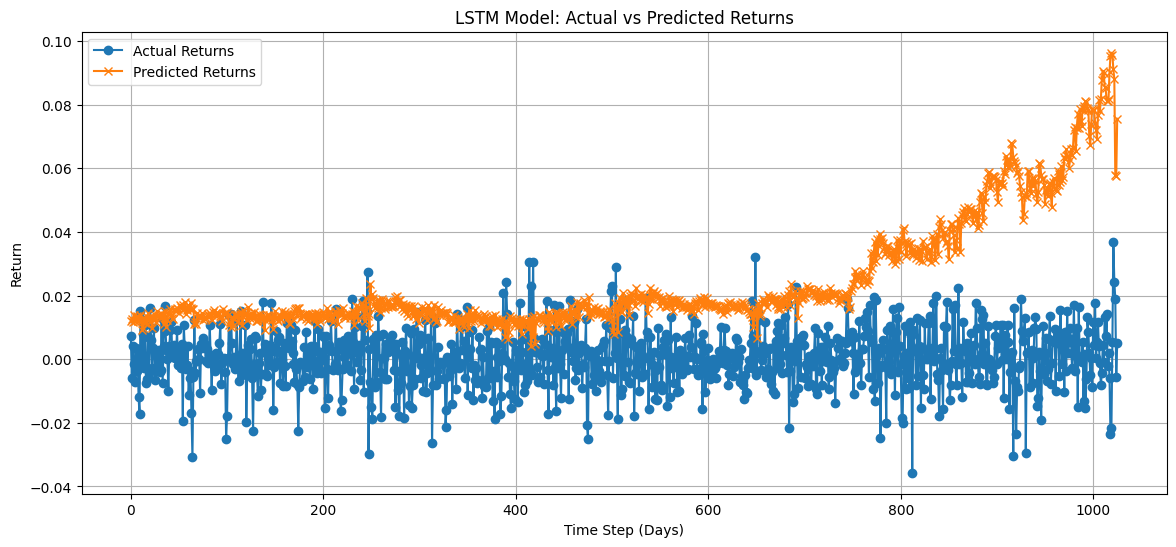

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, r2_score

df['Return'] = df['Close'].pct_change().shift(-1)  # percentage return for next day
df.dropna(inplace=True)  # remove NaNs caused by shifting


window_size = 3  # use past 3 days to predict next day return

X, y = [], []
close_prices = df['Close'].values
returns = df['Return'].values

for i in range(window_size, len(close_prices)):
    X.append(close_prices[i-window_size:i])
    y.append(returns[i])

X = np.array(X)
y = np.array(y)

# Reshape for LSTM input (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))


split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential([
    LSTM(50, activation='relu', input_shape=(window_size, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=1)


y_pred = model.predict(X_test).flatten()

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
actual_direction = np.sign(y_test)
predicted_direction = np.sign(y_pred)
directional_accuracy = np.mean(actual_direction == predicted_direction)
mae_percentage = (mae / np.mean(np.abs(y_test))) * 100  # relative to avg abs returns

# Print metrics
print(f"MAE: {mae:.6f}")
print(f"R² Score: {r2:.6f}")
print(f"Directional Accuracy: {directional_accuracy*100:.2f}%")
print(f"MAE as Percentage of Average Return: {mae_percentage:.2f}%")

# 8. Plot Results

plt.figure(figsize=(14,6))
plt.plot(y_test, label='Actual Returns', linestyle='-', marker='o')
plt.plot(y_pred, label='Predicted Returns', linestyle='-', marker='x')
plt.title('LSTM Model: Actual vs Predicted Returns')
plt.xlabel('Time Step (Days)')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
plt.show()